# PDDL vs ABD baseline, tiers 1 and 2

**Question.** 
Does a general PDDL planner on our LEGO domain produce plans as good as the
assembly-by-disassembly (ABD) planner of the WorkBenchMark paper, and do both execute equally well
through the same TAMPanda executor?

**Baselines.**
(a) *ABD local*: `plan_assembly` from lego_sim, run on the same tasks, same executor.
(b) *ABD paper*: 2nd option which is the published numbers (Table 2, simulation track) published on the paper. Just a reference

**Metric mapping** (ours -> paper): all bricks within tolerance = success;
fraction of bricks within tolerance ~ execution accuracy; bricks not welded ~ stability violation;
planning time = symbolic planning only (paper: perception + reasoning + motion planning).

**Setup.** Domain `lego_coarse_simple_v2.pddl`, bridge `LegoCoarseSimpleV2SLSWeldBridge`, Fast Downward,
tolerances of `SimpleLegoScene.check_goal` (6 mm, 6 mm, 6 deg), seed 42, every 5th task per tier.

In [3]:
import glob, time
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from unified_planning.shortcuts import get_environment
get_environment().credits_stream = None

from yaml_loader import load_task
from scenes import SimpleLegoScene
from bridges import LegoCoarseSimpleV2SLSWeldBridge as Bridge, execute_plan
from eval_baseline import abd_plan, pddl_plan, compare_orders, abd_to_actions, measure

TIERS, EVERY, SEED = (1, 2), 5, 42
DOMAIN = "domains/lego_coarse_simple_v2.pddl"
RESULTS = Path("../results"); (RESULTS / "figures").mkdir(parents=True, exist_ok=True)

In [4]:
#Task selection


tasks = [f for t in TIERS for f in sorted(glob.glob(f"dataset/ground_truth/tier{t}/task_*.yaml"))[::EVERY]]
print(len(tasks), "tasks")
print([Path(f).parent.name + "/" + Path(f).stem for f in tasks])

40 tasks
['tier1/task_001', 'tier1/task_006', 'tier1/task_011', 'tier1/task_016', 'tier1/task_021', 'tier1/task_026', 'tier1/task_031', 'tier1/task_036', 'tier1/task_041', 'tier1/task_046', 'tier1/task_051', 'tier1/task_056', 'tier1/task_061', 'tier1/task_066', 'tier1/task_071', 'tier1/task_076', 'tier1/task_081', 'tier1/task_086', 'tier1/task_091', 'tier1/task_096', 'tier2/task_001', 'tier2/task_006', 'tier2/task_011', 'tier2/task_016', 'tier2/task_021', 'tier2/task_026', 'tier2/task_031', 'tier2/task_036', 'tier2/task_041', 'tier2/task_046', 'tier2/task_051', 'tier2/task_056', 'tier2/task_061', 'tier2/task_066', 'tier2/task_071', 'tier2/task_076', 'tier2/task_081', 'tier2/task_086', 'tier2/task_091', 'tier2/task_096']


In [5]:
#The planning loop (writes the CSV after every task)

rows = []
for f in tasks:                                   
    tier, name = int(f.split("tier")[1][0]), Path(f).stem
    bricks, _ = load_task(f, f)
    scene = SimpleLegoScene(bricks, seed=SEED)
    scene.env.ik.solver = "daqp"
    abd = abd_plan(bricks, name)
    pddl = pddl_plan(bricks, scene, Bridge, DOMAIN)
    cmp = compare_orders(pddl["order"], abd["order"], bricks)
    
    rows.append({"tier": tier, "task": name, "n_bricks": len(bricks),
                 "abd_steps": abd["steps"], "abd_time_ms": round(abd["time_ms"], 3), "abd_order": " ".join(abd["order"]),
                 "pddl_solved": pddl["solved"], "pddl_pairs": pddl["pairs"], "pddl_time_s": round(pddl["time_s"], 3),
                 "pddl_order": " ".join(pddl["order"]), "order_valid": cmp["valid"], "order_equal_abd": cmp["equal"]})
    
    pd.DataFrame(rows).to_csv(RESULTS / "planning.csv", index=False)
    scene.env.close()
    print(f"tier{tier} {name}: pddl {pddl['pairs']} pairs {pddl['time_s']:.2f}s | abd {abd['steps']} steps | "
          f"valid={cmp['valid']} equal={cmp['equal']}")

tier1 task_001: pddl 2 pairs 0.49s | abd 2 steps | valid=True equal=True
tier1 task_006: pddl 2 pairs 0.15s | abd 2 steps | valid=True equal=True
tier1 task_011: pddl 2 pairs 0.13s | abd 2 steps | valid=True equal=True
tier1 task_016: pddl 2 pairs 0.13s | abd 2 steps | valid=True equal=True
tier1 task_021: pddl 2 pairs 0.13s | abd 2 steps | valid=True equal=True
tier1 task_026: pddl 2 pairs 0.22s | abd 2 steps | valid=True equal=True
tier1 task_031: pddl 2 pairs 0.13s | abd 2 steps | valid=True equal=True
tier1 task_036: pddl 2 pairs 0.13s | abd 2 steps | valid=True equal=True
tier1 task_041: pddl 2 pairs 0.17s | abd 2 steps | valid=True equal=True
tier1 task_046: pddl 2 pairs 0.13s | abd 2 steps | valid=True equal=True
tier1 task_051: pddl 2 pairs 0.12s | abd 2 steps | valid=True equal=True
tier1 task_056: pddl 2 pairs 0.18s | abd 2 steps | valid=True equal=True
tier1 task_061: pddl 2 pairs 0.14s | abd 2 steps | valid=True equal=True
tier1 task_066: pddl 2 pairs 0.13s | abd 2 steps | 

In [6]:

#planning summary

df = pd.read_csv(RESULTS / "planning.csv")
summary = df.groupby("tier").agg(
    tasks=("task", "count"), pddl_solved=("pddl_solved", "mean"),
    pddl_pairs=("pddl_pairs", "mean"), abd_steps=("abd_steps", "mean"),
    pddl_time_s=("pddl_time_s", "mean"), abd_time_ms=("abd_time_ms", "mean"),
    order_valid=("order_valid", "mean"), order_equal_abd=("order_equal_abd", "mean")).round(3)
summary

,tasks,pddl_solved,pddl_pairs,abd_steps,pddl_time_s,abd_time_ms,order_valid,order_equal_abd
tier,,,,,,,,
1,20,1.0,2.00,2.00,0.17,0.181,1.0,1.0
2,20,1.0,2.95,2.95,0.16,0.121,1.0,1.0


In [7]:
df = pd.read_csv(RESULTS / "planning.csv")
df["pddl_time_ms"] = 1000 * df["pddl_time_s"]          # to get same unit as abd_time_ms
summary = df.groupby("tier").agg(
    tasks=("task", "count"),
    pddl_solved=("pddl_solved", "mean"),
    pddl_pairs=("pddl_pairs", "mean"),
    abd_steps=("abd_steps", "mean"),
    pddl_time_ms=("pddl_time_ms", "mean"),
    abd_time_ms=("abd_time_ms", "mean"),
    order_valid=("order_valid", "mean"),
    order_equal_abd=("order_equal_abd", "mean")).round(2)
summary

,tasks,pddl_solved,pddl_pairs,abd_steps,pddl_time_ms,abd_time_ms,order_valid,order_equal_abd
tier,,,,,,,,
1,20,1.0,2.00,2.00,170.45,0.18,1.0,1.0
2,20,1.0,2.95,2.95,159.90,0.12,1.0,1.0


## Reference: published ABD results (paper Table 2, simulation)

| Metric | Tier 1 | Tier 2 |
|---|---|---|
| Success rate | 94.0 % | 87.0 % |
| Execution accuracy | 91.6 % | 84.9 % |
| Planning time | 6.88 s | 10.35 s |
| Wall time | 15.92 s | 23.68 s |
| Stability violations | 3.0 % | 5.8 % |

These are reference values, not a same-conditions comparison: the paper's planning time includes
perception (GroundingDINO, SAM, FoundationPose), it runs in lego_sim with stud physics on all 100
tasks per tier, and its success requires bricks to be attached to the structure. Our numbers are
symbolic planning only, TAMPanda with welding, 20 tasks per tier, pose tolerances.

## Execution: both planners through the same executor

`run_eval.py` executes, per task, first the PDDL plan and then the ABD order, each on a fresh
scene with seed 42, through `LegoCoarseSimpleV2SLSWeldBridge`. Metrics per run: success, fraction of
bricks within tolerance, fraction welded, simulation time. Differences between the two rows of a task
come from the plan only, because everything else is identical.

In [9]:
ex = pd.read_csv(RESULTS / "execution_seed42.csv")
exs = ex.groupby(["tier", "planner"]).agg(
    tasks=("task", "count"), executed=("executed", "mean"), success=("success", "mean"),
    placed_frac=("placed_frac", "mean"), welded_frac=("welded_frac", "mean"),
    sim_time_s=("sim_time_s", "mean"), wall_s=("wall_s", "mean")).round(3)
exs

tasks  executed  success  placed_frac  welded_frac  sim_time_s  \
tier planner                                                                   
1    abd         31       1.0      1.0          1.0          1.0      19.483   
     pddl        31       1.0      1.0          1.0          1.0       9.647   
2    abd         25       1.0      1.0          1.0          1.0      27.535   
     pddl        25       1.0      1.0          1.0          1.0      13.670   

              wall_s  
tier planner          
1    abd      29.342  
     pddl     29.477  
2    abd      42.324  
     pddl     42.552

In [10]:
#comparison table ours vs ABD local vs ABD paper


paper = pd.DataFrame({"tier": [1, 2], "success": [0.94, 0.87], "placed_frac": [0.916, 0.849],
                      "planning_time_s": [6.88, 10.35]}).set_index("tier")
plan = df.groupby("tier")[["pddl_time_s", "abd_time_ms"]].mean()
table = pd.DataFrame({
    "PDDL success":   exs.xs("pddl", level="planner")["success"],
    "ABD local success": exs.xs("abd", level="planner")["success"],
    "ABD paper success": paper["success"],
    "PDDL bricks ok":  exs.xs("pddl", level="planner")["placed_frac"],
    "ABD local bricks ok": exs.xs("abd", level="planner")["placed_frac"],
    "ABD paper exec. acc.": paper["placed_frac"],
    "PDDL plan time s": plan["pddl_time_s"],
    "ABD local plan time s": plan["abd_time_ms"] / 1000,
    "ABD paper plan time s (incl. perception)": paper["planning_time_s"],
}).round(3)
table.T

tier,1,2
PDDL success,1.000,1.000
ABD local success,1.000,1.000
ABD paper success,0.940,0.870
PDDL bricks ok,1.000,1.000
ABD local bricks ok,1.000,1.000
ABD paper exec. acc.,0.916,0.849
PDDL plan time s,0.170,0.160
ABD local plan time s,0.000,0.000
ABD paper plan time s (incl. perception),6.880,10.350


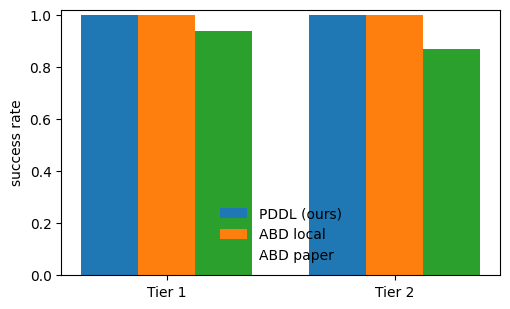

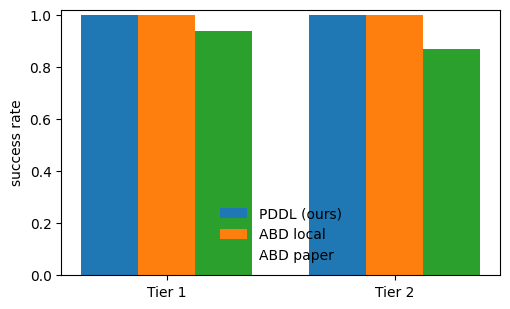

In [11]:
tiers = [1, 2]; w = 0.25
series = [("PDDL (ours)", exs.xs("pddl", level="planner")["success"]),
          ("ABD local", exs.xs("abd", level="planner")["success"]),
          ("ABD paper", paper["success"])]
fig, ax = plt.subplots(figsize=(5.2, 3.2))
for i, (label, s) in enumerate(series):
    ax.bar([t + (i - 1) * w for t in tiers], [float(s.get(t, 0)) for t in tiers], w, label=label)
ax.set_xticks(tiers); ax.set_xticklabels([f"Tier {t}" for t in tiers])
ax.set_ylim(0, 1.02); ax.set_ylabel("success rate"); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(RESULTS / "figures" / "success_by_tier.png", dpi=200); fig